In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D
)


In [2]:
# Load Dataset from Local CSV File

import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Read dataset
df = pd.read_csv("imdb_top_1000.csv")

# Use movie overview as text data
X = df["Overview"].astype(str).values

# Create labels using IMDB rating
# Rating >= 7.5 => Positive (1)
# Rating < 7.5 => Negative (0)

y = (df["IMDB_Rating"] >= 7.5).astype(int).values

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Tokenization
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

# Padding
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 800
Testing samples: 200


In [3]:
# Preprocess Data
# Pad sequences so all reviews have same length
max_sequence_length = 500

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train,
    maxlen=max_sequence_length
)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test,
    maxlen=max_sequence_length
)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)



Shape of x_train: (800, 500)
Shape of x_test: (200, 500)


In [4]:
# Build Neural Network Model
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=max_words,
        output_dim=100,
        input_length=max_sequence_length
    )
)

# Global Max Pooling Layer
model.add(GlobalMaxPooling1D())

# Hidden Layer
model.add(Dense(256, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))



C:\Users\Om Abhang\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
# Compile Model

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train Model
batch_size = 64
epochs = 10

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2
)



Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9141 - loss: 0.3953 - val_accuracy: 1.0000 - val_loss: 0.0626
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 0.0198 - val_accuracy: 1.0000 - val_loss: 8.2373e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 1.0000 - loss: 5.8220e-04 - val_accuracy: 1.0000 - val_loss: 5.7298e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 9.6649e-05 - val_accuracy: 1.0000 - val_loss: 1.6683e-05
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 4.4035e-05 - val_accuracy: 1.0000 - val_loss: 9.8323e-06
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 3.4431e-05 - val_accuracy: 1.0000 - val_loss: 7.8586e-06
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 1.0000 - loss: 2.2849e-05 - val_accuracy: 1.0000 - val_loss: 7.1128e-06
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0

In [7]:
# Generate Predictions
y_pred_probs = model.predict(x_test)

# Convert probabilities to binary labels
y_pred = (y_pred_probs > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


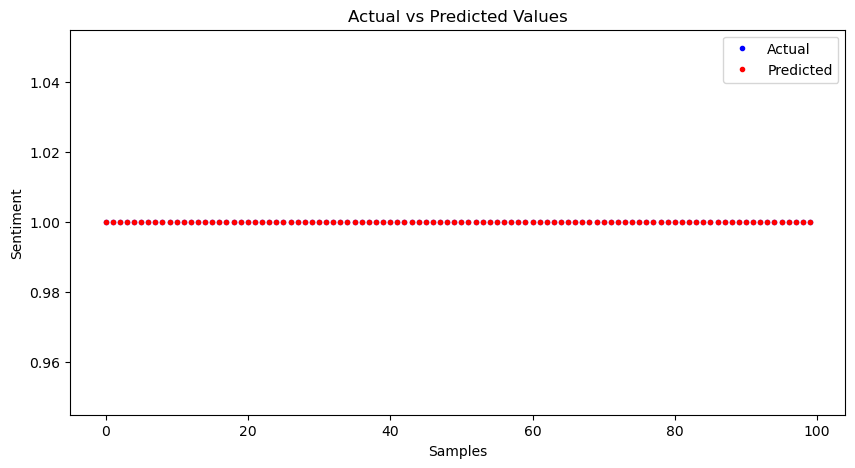

In [8]:
# Plot Actual vs Predicted Values
plt.figure(figsize=(10, 5))

plt.plot(y_test[:100], 'b.', label='Actual')
plt.plot(y_pred[:100], 'r.', label='Predicted')

plt.title('Actual vs Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Sentiment')

plt.legend()
plt.show()

In [9]:
# Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 6.3795e-06

Test Loss: 6.379538262990536e-06
Test Accuracy: 1.0


C:\Users\Om Abhang\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


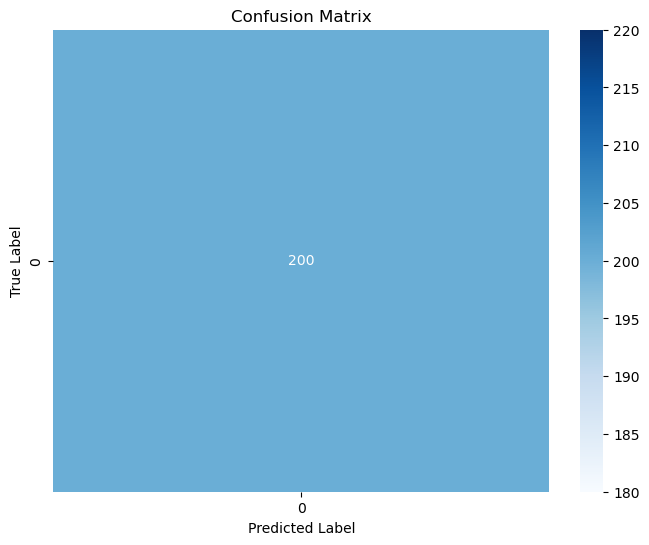


Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [10]:
# Confusion Matrix & Classification Report

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Generate classification report
classification_rep = classification_report(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Print classification report
print("\nClassification Report:\n")
print(classification_rep)

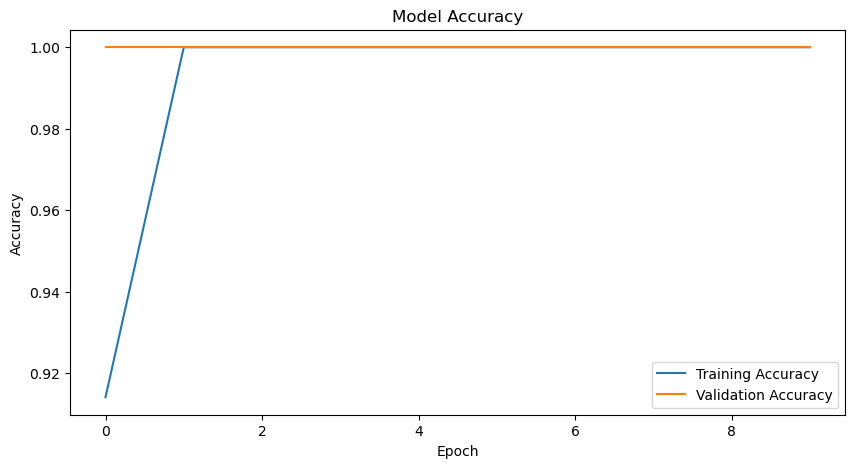

In [11]:
# =========================================================
# Plot Accuracy Graph
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

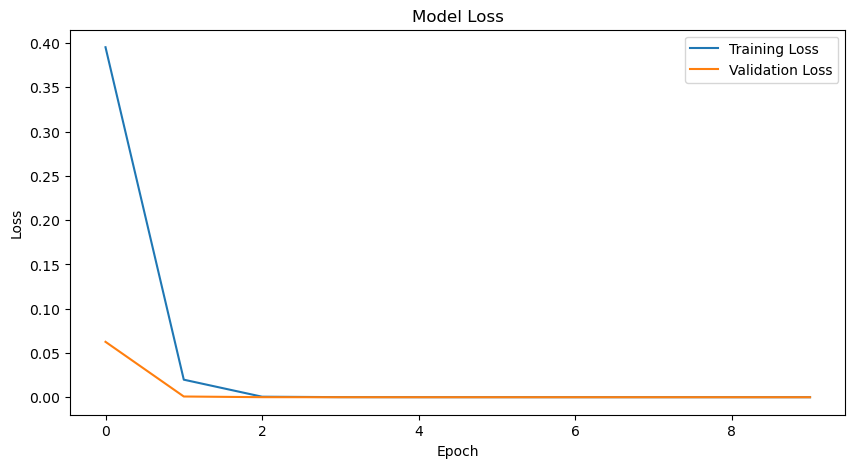

In [12]:
# =========================================================
# Plot Loss Graph
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()